In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [2]:
import skrf as rf
import matplotlib.pyplot as plt

In [ ]:
filename1 = 'TEST_250125_298K.s2p'
filename2 = 'TEST_250125_273K.s2p'
filename3 = 'TEST_250125_255K.s2p'
filename4 = 'TEST_250125_240K.s2p'
filename5 = 'TEST_250125_210K.s2p'
filename6 = 'TEST_250125_165K.s2p'
filename7 = 'TEST_250125_150K.s2p'
filename8 = 'TEST_250125_110K.s2p'
filename9 = 'TEST_250125_90K.s2p'
filename10 = 'TEST_250125_85K.s2p'
filename11 = 'TEST_250125_80K.s2p'
filename12 = 'TEST_250125_79K.s2p'
filename13 = 'TEST_250125_77K.s2p'

In [ ]:
# for i in range(5):
#     exec(f"var_{i} = {i}")
#     exec(f"print('var_{i} =', var_{i})")


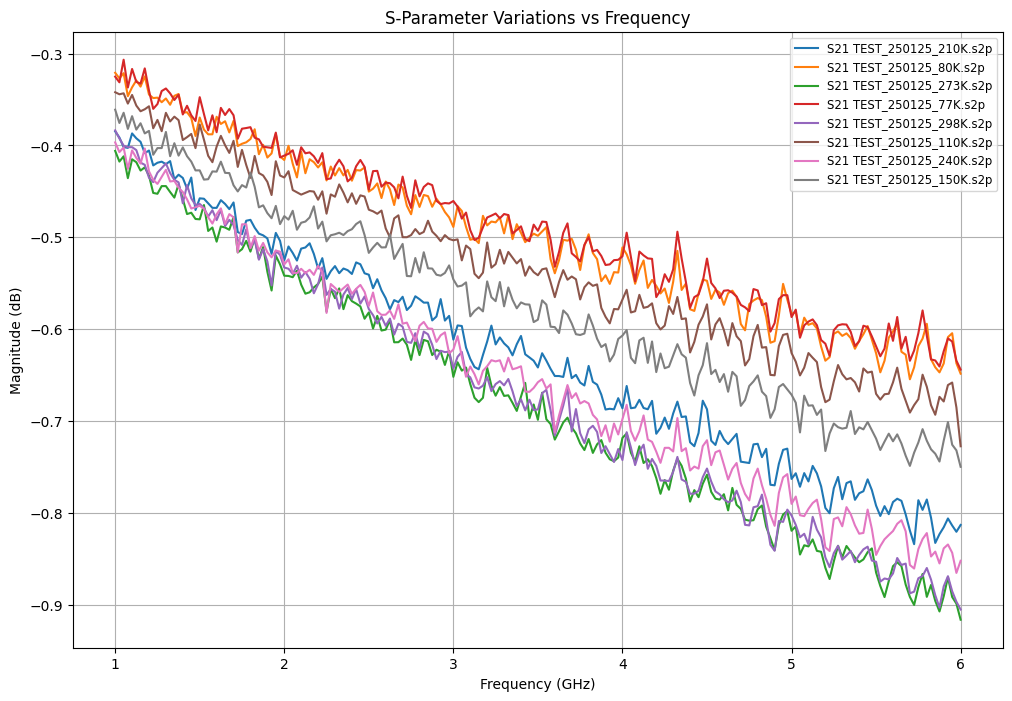

In [20]:
import os
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np

# Directory containing the .s2p files
s2p_directory = 's2p_files'

# Initialize a plot
plt.figure(figsize=(12, 8))

# Loop through all .s2p files in the directory
for filename in os.listdir(s2p_directory):
    if filename.endswith('.s2p'):
        file_path = os.path.join(s2p_directory, filename)
        
        # Read the .s2p file
        network = rf.Network(file_path)
        
        # Extract frequency and S-parameters
        frequency = network.f  # Frequency in Hz
        s11 = network.s[:, 0, 0]  # S11
        s21 = network.s[:, 1, 0]  # S21
        
        # Convert frequency to GHz for plotting
        frequency_ghz = frequency / 1e9

        # Plot S11 magnitude (in dB)
        plt.plot(frequency_ghz, 20 * np.log10(abs(s21)), label=f'S21 {filename}')
        # You can add more S-parameters like S21 if needed

# Customize plot
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S-Parameter Variations vs Frequency')
plt.legend(loc='best', fontsize='small')
plt.grid()
plt.show()


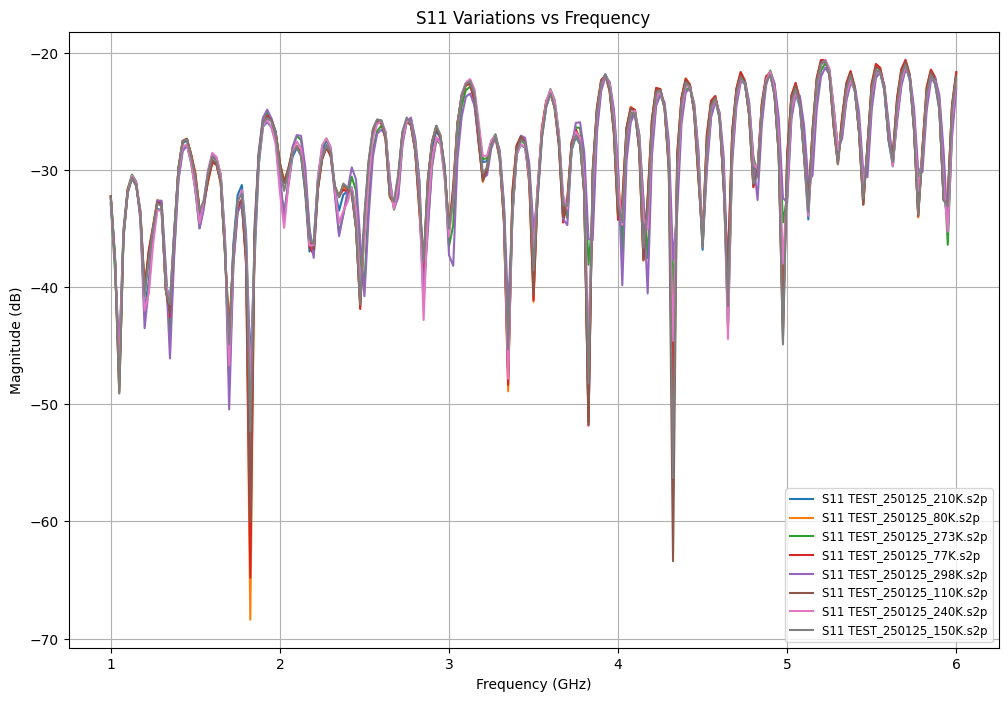

In [22]:
plt.figure(figsize=(12, 8))
for filename in os.listdir(s2p_directory):
    if filename.endswith('.s2p'):
        file_path = os.path.join(s2p_directory, filename)
        
        # Read the .s2p file
        network = rf.Network(file_path)
        
        # Extract frequency and S-parameters
        frequency = network.f  # Frequency in Hz
        s11 = network.s[:, 0, 0]  # S11
        s21 = network.s[:, 1, 0]  # S21
        
        # Convert frequency to GHz for plotting
        frequency_ghz = frequency / 1e9

        # Plot S11 magnitude (in dB)
        plt.plot(frequency_ghz, 20 * np.log10(abs(s11)), label=f'S11 {filename}')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S11 Variations vs Frequency')
plt.legend(loc='best', fontsize='small')
plt.grid()
plt.show()

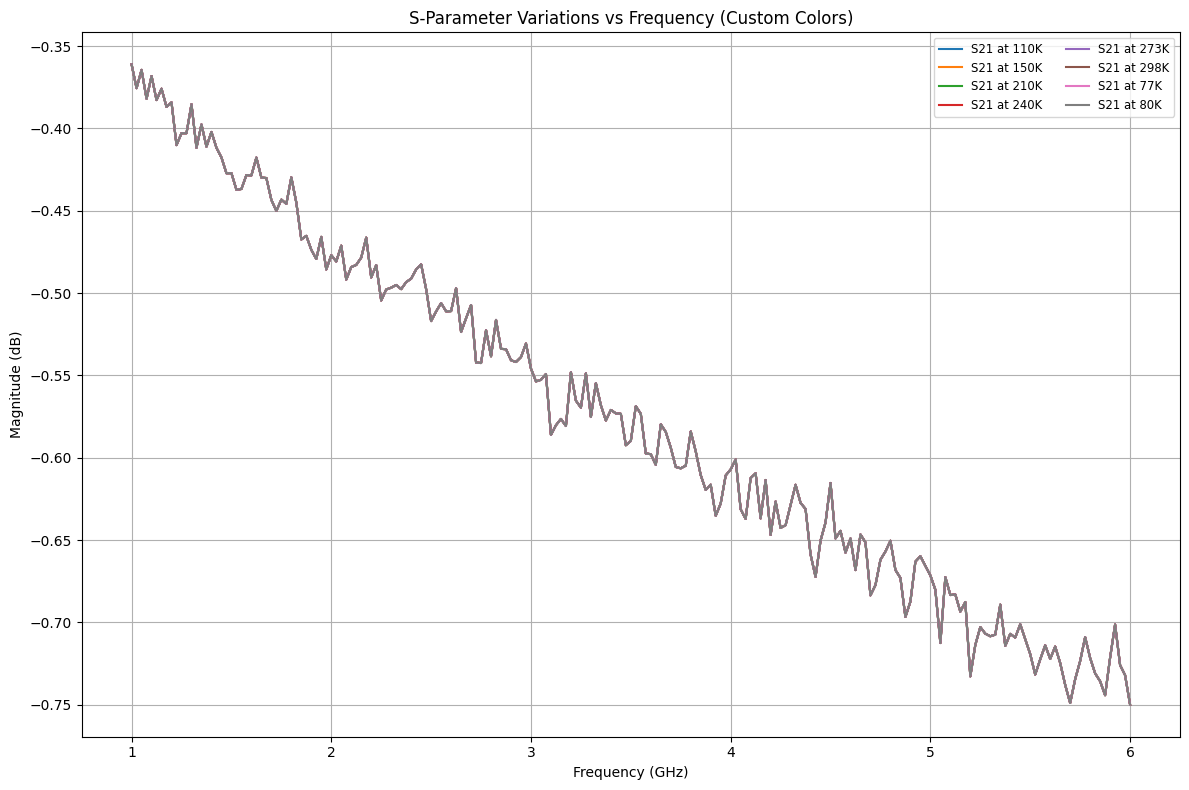

In [15]:
import os
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
import re

# Directory containing the .s2p files
s2p_directory = 's2p_files'

# Define a custom color scheme
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f']

#custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
#                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Initialize a plot
plt.figure(figsize=(12, 8))

# File counter to assign colors
file_counter = 0

# Loop through all .s2p files in the directory
for filename in sorted(os.listdir(s2p_directory)):  # Sorting for consistent order
    if filename.endswith('.s2p'):
        # Extract temperature from filename (if encoded)
        match = re.search(r'(\d+)K', filename)
        temperature = f"{match.group(1)}K" if match else 'Unknown'

        # Read the .s2p file
        file_path = os.path.join(s2p_directory, filename)
        network = rf.Network(file_path)

        # Extract frequency and S-parameters
        frequency = network.f  # Frequency in Hz
        s11 = network.s[:, 0, 0]  # S11
        frequency_ghz = frequency / 1e9

        # Assign a color from the custom color scheme
        color = custom_colors[file_counter % len(custom_colors)]
        file_counter += 1

        # Plot S11 magnitude (in dB) with the assigned color
        plt.plot(frequency_ghz, 20 * np.log10(abs(s21)), label=f'S21 at {temperature}', color=color)

# Customize plot
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S-Parameter Variations vs Frequency (Custom Colors)')
plt.legend(loc='best', fontsize='small', ncol=2)  # Use multiple columns for compact legends
plt.grid()
plt.tight_layout()
plt.show()


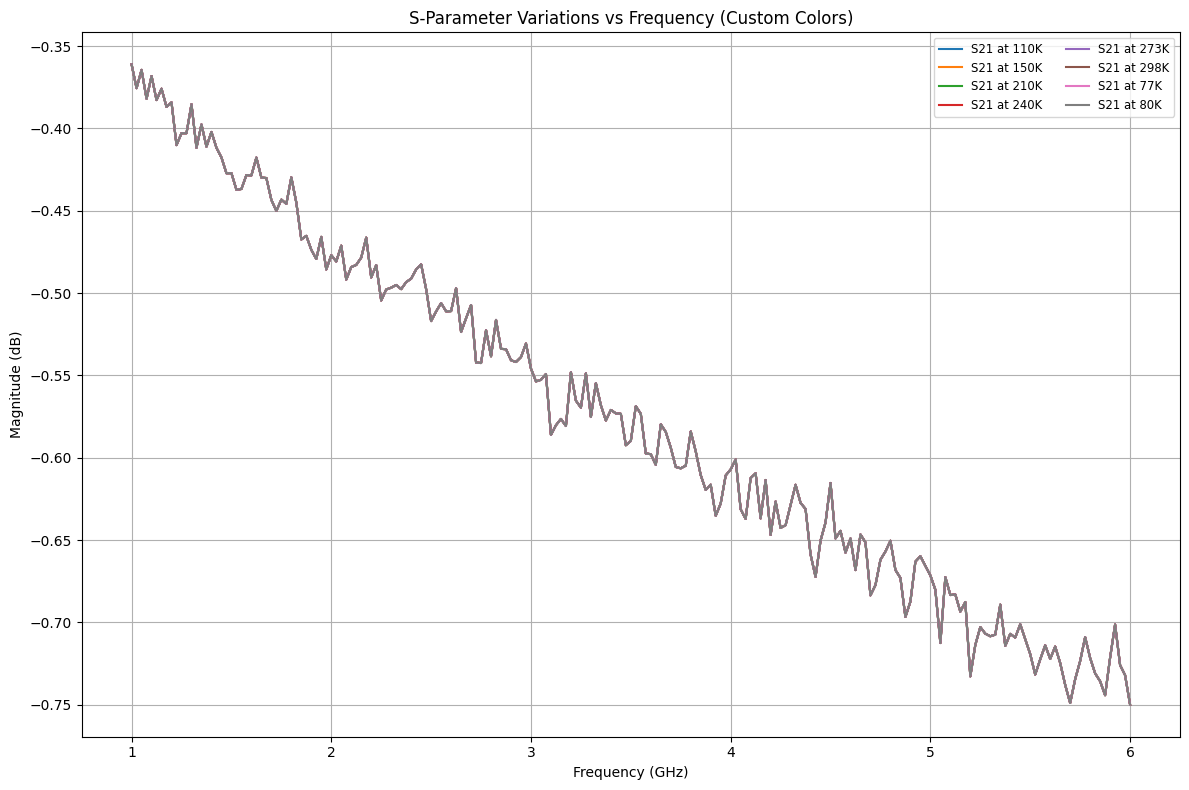

In [17]:
import os
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
import re

# Directory containing the .s2p files
s2p_directory = 's2p_files'

# Define a custom color scheme
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f']

# Initialize a plot
plt.figure(figsize=(12, 8))

# File counter to assign colors
file_counter = 0

# Loop through all .s2p files in the directory
for filename in sorted(os.listdir(s2p_directory)):  # Sorting for consistent order
    if filename.endswith('.s2p'):
        # Extract temperature from filename (if encoded)
        match = re.search(r'(\d+)K', filename)
        temperature = f"{match.group(1)}K" if match else 'Unknown'

        # Read the .s2p file
        file_path = os.path.join(s2p_directory, filename)
        network = rf.Network(file_path)  # Load the network data

        # Check if the network is valid and has data
        if network.s is not None and network.s.size > 0:
            # Extract frequency and S-parameters
            frequency = network.f  # Frequency in Hz
            s11 = network.s[:, 0, 0]  # S11
            frequency_ghz = frequency / 1e9

            # Assign a color from the custom color scheme
            color = custom_colors[file_counter % len(custom_colors)]
            file_counter += 1

            # Plot S11 magnitude (in dB) with the assigned color
            plt.plot(frequency_ghz, 20 * np.log10(abs(s21)), label=f'S21 at {temperature}', color=color)
        else:
            print(f"Warning: Skipping file {filename} due to invalid or empty data.")

# Customize plot
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S-Parameter Variations vs Frequency (Custom Colors)')
plt.legend(loc='best', fontsize='small', ncol=2)  # Use multiple columns for compact legends
plt.grid()
plt.tight_layout()
plt.show()


In [3]:
i=1


network = rf.Network(filename)

# Extract frequency and S-parameters
frequency = network.f  # Frequency in Hz
s11 = network.s[:, 0, 0]  # S11
s12 = network.s[:, 0, 1]  # S12
s21 = network.s[:, 1, 0]  # S21
s22 = network.s[:, 1, 1]  # S22

# Convert frequency to GHz for plotting
frequency_ghz = frequency / 1e9


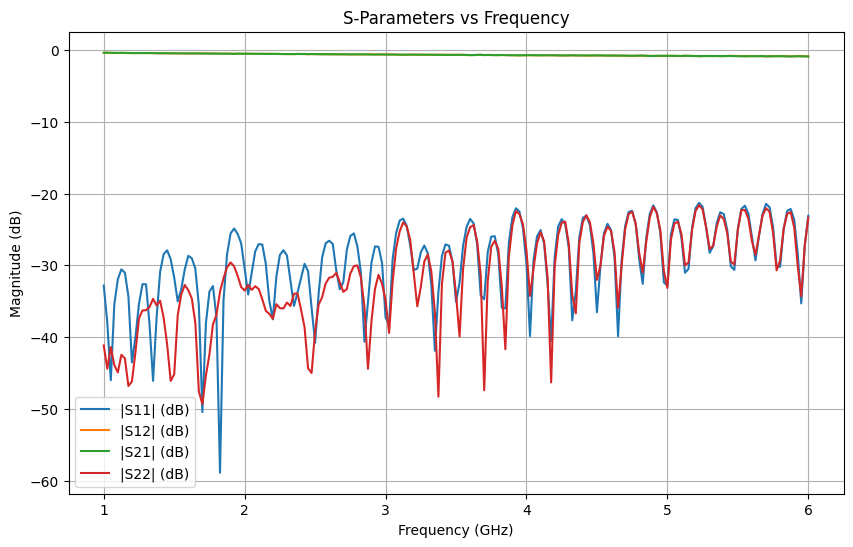

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(frequency_ghz, 20 * np.log10(abs(s11)), label='|S11| (dB)')
plt.plot(frequency_ghz, 20 * np.log10(abs(s12)), label='|S12| (dB)')
plt.plot(frequency_ghz, 20 * np.log10(abs(s21)), label='|S21| (dB)')
plt.plot(frequency_ghz, 20 * np.log10(abs(s22)), label='|S22| (dB)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('S-Parameters vs Frequency')
plt.legend()
plt.grid()
plt.show()